In [ ]:
#importaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
np.random.seed(SEED)
print("Librerias cargadas correctamente")

In [ ]:
# Carga y limpieza de datos
START = "2021-01-01"
END   = "2025-12-31"

# BZ=F = Brent Crude Oil Futures (equivalente a DCOILBRENTEU de FRED)
raw = yf.download("BZ=F", start=START, end=END, auto_adjust=True, progress=False)

# yfinance puede devolver columnas multi-nivel; aplanar si es necesario
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[["Close"]].copy()
df.columns = ["price"]
df.index.name = "date"

# Contar y eliminar NaNs (fines de semana / festivos sin cotización)
nan_count = int(df["price"].isna().sum())
df = df.dropna()

print(f"Datos descargados: {len(df)} registros ({START} -> {END})")
print(f"NaNs eliminados: {nan_count}")
print(f"Primeras filas:")
print(df.head())
print(f"Ultimas filas:")
print(df.tail())

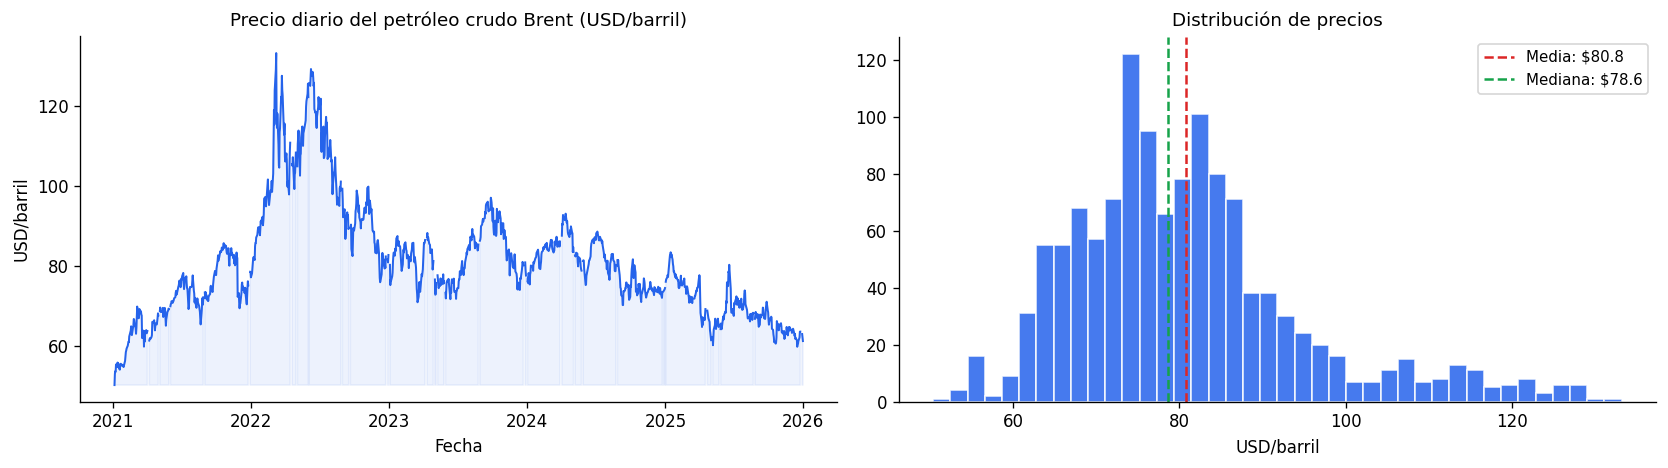

💾 Guardado: fig_eda_serie_distribucion.png
Estadísticas descriptivas:
count    1263.00
mean       80.77
std        14.02
min        50.37
25%        71.84
50%        78.63
75%        86.48
max       133.18

Rendimiento diario promedio: 0.0473%
Volatilidad (std): 2.1955%

Días con precio al alza: 652 (53.2%)
Días con precio a la baja: 574 (46.8%)
Balance de clases (target clasificación): 53.2% vs 46.8%


In [ ]:
#Analisis exploratorio de datos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
# Serie temporal
axes[0].plot(df.index, df['price'], linewidth=1.2, color='#2563EB')
axes[0].fill_between(df.index, df['price'], df['price'].min(), alpha=0.08, color='#2563EB')
axes[0].set_title('Precio diario del petróleo crudo Brent (USD/barril)', fontsize=11)
axes[0].set_ylabel('USD/barril')
axes[0].set_xlabel('Fecha')
 
# Distribución
axes[1].hist(df['price'], bins=40, color='#2563EB', edgecolor='white', alpha=0.85)
axes[1].axvline(df['price'].mean(), color='#DC2626', linestyle='--', label=f'Media: ${df["price"].mean():.1f}')
axes[1].axvline(df['price'].median(), color='#16A34A', linestyle='--', label=f'Mediana: ${df["price"].median():.1f}')
axes[1].set_title('Distribución de precios', fontsize=11)
axes[1].set_xlabel('USD/barril')
axes[1].legend(fontsize=9)
 
plt.tight_layout()
plt.savefig('fig_eda_serie_distribucion.png', bbox_inches='tight')
plt.show()
print('Guardado: fig_eda_serie_distribucion.png')
 
# Estadísticas descriptivas
stats = df['price'].describe()
print('Estadísticas descriptivas:')
print(stats.round(2).to_string())
 
# Rendimientos diarios
df['returns'] = df['price'].pct_change() * 100
print(f'\nRendimiento diario promedio: {df["returns"].mean():.4f}%')
print(f'Volatilidad (std): {df["returns"].std():.4f}%')
 
# Proporción de días que subió vs bajó
up_days   = (df['returns'] > 0).sum()
down_days = (df['returns'] < 0).sum()
total     = up_days + down_days
print(f'\nDías con precio al alza: {up_days} ({up_days/total*100:.1f}%)')
print(f'Días con precio a la baja: {down_days} ({down_days/total*100:.1f}%)')
print(f'Balance de clases (target clasificación): {up_days/total*100:.1f}% vs {down_days/total*100:.1f}%')

Dataset supervisado: 1117 muestras, 5 features
Balance de clases — Sube (1): 579 (51.8%) | Baja (0): 538 (48.2%)
Entrenamiento: 893 muestras
Prueba       : 224 muestras

Rango post-normalización — min: 0.000, max: 1.000


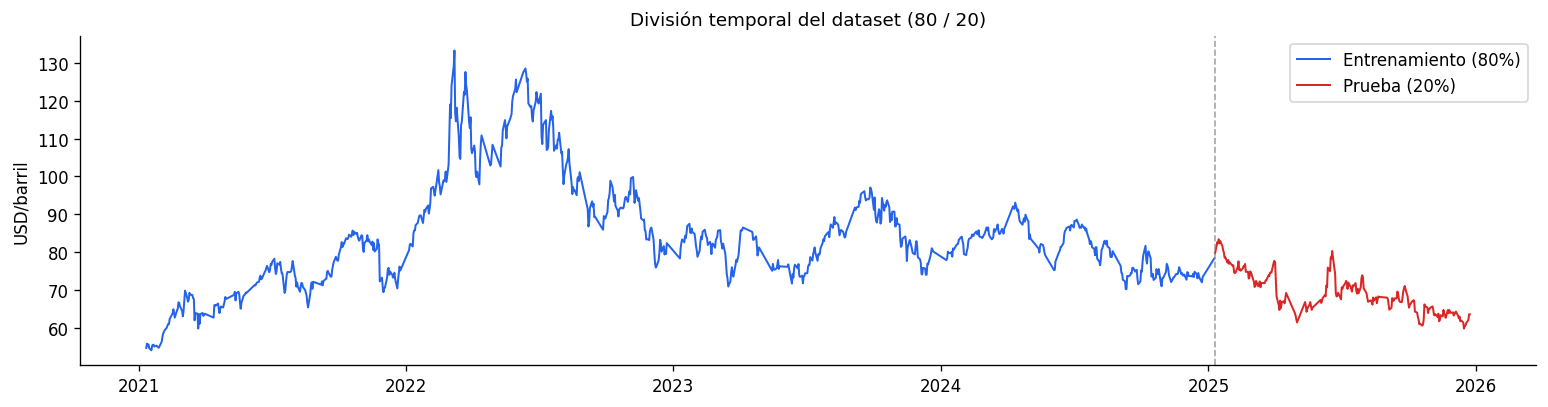

Guardado: fig_split_temporal.png


In [24]:
#Preprosesamiento Ventana de Lags
LAG = 5  # Ventana de días previos como features
 
# ── Crear features (lags) y target (clasificación binaria) ──
def build_features(series, n_lags=5):
    df_out = pd.DataFrame(index=series.index)
    for i in range(1, n_lags + 1):
        df_out[f'lag_{i}'] = series.shift(i)
    # Target: 1 si el precio del día siguiente sube, 0 si baja
    df_out['target'] = (series.shift(-1) > series).astype(int)
    # Precio actual (para referencia)
    df_out['price'] = series
    return df_out.dropna()
 
feat_df = build_features(df['price'], n_lags=LAG)
 
feature_cols = [f'lag_{i}' for i in range(1, LAG + 1)]
X = feat_df[feature_cols].values
y = feat_df['target'].values
 
print(f'Dataset supervisado: {X.shape[0]} muestras, {X.shape[1]} features')
print(f'Balance de clases — Sube (1): {y.sum()} ({y.mean()*100:.1f}%) | Baja (0): {(1-y).sum()} ({(1-y).mean()*100:.1f}%)')
 
# ── Split temporal 80/20 (NO aleatorio — respeta el orden cronológico) ──
split_idx = int(len(X) * 0.80)
 
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
 
print(f'Entrenamiento: {len(X_train)} muestras')
print(f'Prueba       : {len(X_test)} muestras')
 
# ── Normalización Min-Max (requerida para KNN y redes neuronales) ──
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit SOLO en train
X_test_sc  = scaler.transform(X_test)       # transform en test
 
print(f'\nRango post-normalización — min: {X_train_sc.min():.3f}, max: {X_train_sc.max():.3f}')
 
# Visualización del split temporal
prices = feat_df['price'].values
dates  = feat_df.index
 
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(dates[:split_idx],  prices[:split_idx],  color='#2563EB', label='Entrenamiento (80%)', linewidth=1.2)
ax.plot(dates[split_idx:],  prices[split_idx:],  color='#DC2626', label='Prueba (20%)',        linewidth=1.2)
ax.axvline(dates[split_idx], color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('División temporal del dataset (80 / 20)', fontsize=11)
ax.set_ylabel('USD/barril')
ax.legend()
plt.tight_layout()
plt.savefig('fig_split_temporal.png', bbox_inches='tight')
plt.show()
print('Guardado: fig_split_temporal.png')

Mejor K: 7  (CV accuracy: 51.85%)


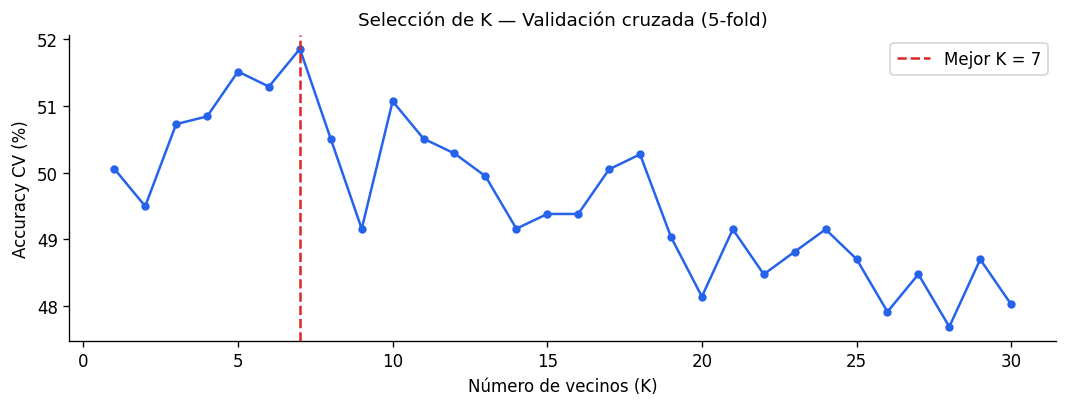

Guardado: fig_knn_k_selection.png
=== KNN — Resultados en conjunto de prueba ===
  Accuracy  : 49.55%
  Precision : 0.4698
  Recall    : 0.6731
  F1-Score  : 0.5534
  AUC-ROC   : 0.5472

Reporte completo:
              precision    recall  f1-score   support

    Baja (0)       0.55      0.34      0.42       120
    Sube (1)       0.47      0.67      0.55       104

    accuracy                           0.50       224
   macro avg       0.51      0.51      0.49       224
weighted avg       0.51      0.50      0.48       224



In [26]:
#Modelado predictivo
# ── Búsqueda del mejor K ──
k_values  = range(1, 31)
cv_scores = []
 
cv = StratifiedKFold(n_splits=5, shuffle=False)
 
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='accuracy')
    cv_scores.append(scores.mean())
 
best_k = k_values[np.argmax(cv_scores)]
print(f'Mejor K: {best_k}  (CV accuracy: {max(cv_scores)*100:.2f}%)')
 
# Gráfica de selección de K
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(k_values, [s*100 for s in cv_scores], color='#2563EB', marker='o', markersize=4, linewidth=1.5)
ax.axvline(best_k, color='#DC2626', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('Accuracy CV (%)')
ax.set_title('Selección de K — Validación cruzada (5-fold)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('fig_knn_k_selection.png', bbox_inches='tight')
plt.show()
print('Guardado: fig_knn_k_selection.png')
 
# ── Entrenamiento y evaluación final KNN ──
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_model.fit(X_train_sc, y_train)
y_pred_knn  = knn_model.predict(X_test_sc)
y_prob_knn  = knn_model.predict_proba(X_test_sc)[:, 1]
 
knn_acc  = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn)
knn_rec  = recall_score(y_test, y_pred_knn)
knn_f1   = f1_score(y_test, y_pred_knn)
knn_auc  = roc_auc_score(y_test, y_prob_knn)
 
print('=== KNN — Resultados en conjunto de prueba ===')
print(f'  Accuracy  : {knn_acc*100:.2f}%')
print(f'  Precision : {knn_prec:.4f}')
print(f'  Recall    : {knn_rec:.4f}')
print(f'  F1-Score  : {knn_f1:.4f}')
print(f'  AUC-ROC   : {knn_auc:.4f}')
print(f'\nReporte completo:')
print(classification_report(y_test, y_pred_knn, target_names=['Baja (0)', 'Sube (1)']))

Épocas de entrenamiento: 32

=== Red Neuronal (Sigmoide) — Resultados en conjunto de prueba ===
  Accuracy  : 46.43%
  Precision : 0.4643
  Recall    : 1.0000
  F1-Score  : 0.6341
  AUC-ROC   : 0.5407

Reporte completo:
              precision    recall  f1-score   support

    Baja (0)       0.00      0.00      0.00       120
    Sube (1)       0.46      1.00      0.63       104

    accuracy                           0.46       224
   macro avg       0.23      0.50      0.32       224
weighted avg       0.22      0.46      0.29       224



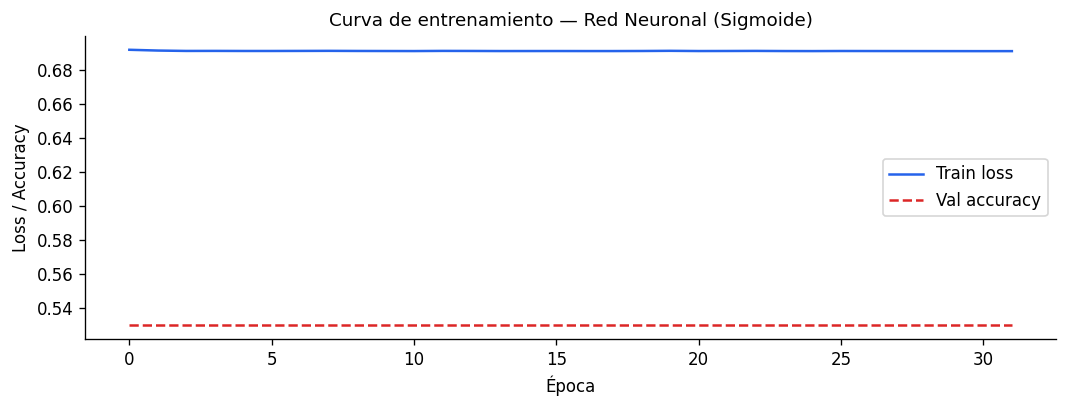

Guardado: fig_nn_loss_curve.png


In [28]:
#Red Neuronal
# ── Red Neuronal con Sigmoide ──
nn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),  # Dos capas ocultas
    activation='logistic',        # Función sigmoide
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=SEED,
    verbose=False
)
 
nn_model.fit(X_train_sc, y_train)
y_pred_nn  = nn_model.predict(X_test_sc)
y_prob_nn  = nn_model.predict_proba(X_test_sc)[:, 1]
 
nn_acc  = accuracy_score(y_test, y_pred_nn)
nn_prec = precision_score(y_test, y_pred_nn)
nn_rec  = recall_score(y_test, y_pred_nn)
nn_f1   = f1_score(y_test, y_pred_nn)
nn_auc  = roc_auc_score(y_test, y_prob_nn)
 
print(f'Épocas de entrenamiento: {nn_model.n_iter_}')
print(f'\n=== Red Neuronal (Sigmoide) — Resultados en conjunto de prueba ===')
print(f'  Accuracy  : {nn_acc*100:.2f}%')
print(f'  Precision : {nn_prec:.4f}')
print(f'  Recall    : {nn_rec:.4f}')
print(f'  F1-Score  : {nn_f1:.4f}')
print(f'  AUC-ROC   : {nn_auc:.4f}')
print(f'\nReporte completo:')
print(classification_report(y_test, y_pred_nn, target_names=['Baja (0)', 'Sube (1)']))
 
# Curva de pérdida (loss curve) de la red neuronal
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(nn_model.loss_curve_, color='#2563EB', linewidth=1.5, label='Train loss')
if hasattr(nn_model, 'validation_scores_'):
    ax.plot(nn_model.validation_scores_, color='#DC2626', linewidth=1.5, linestyle='--', label='Val accuracy')
ax.set_xlabel('Época')
ax.set_ylabel('Loss / Accuracy')
ax.set_title('Curva de entrenamiento — Red Neuronal (Sigmoide)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('fig_nn_loss_curve.png', bbox_inches='tight')
plt.show()
print('Guardado: fig_nn_loss_curve.png')

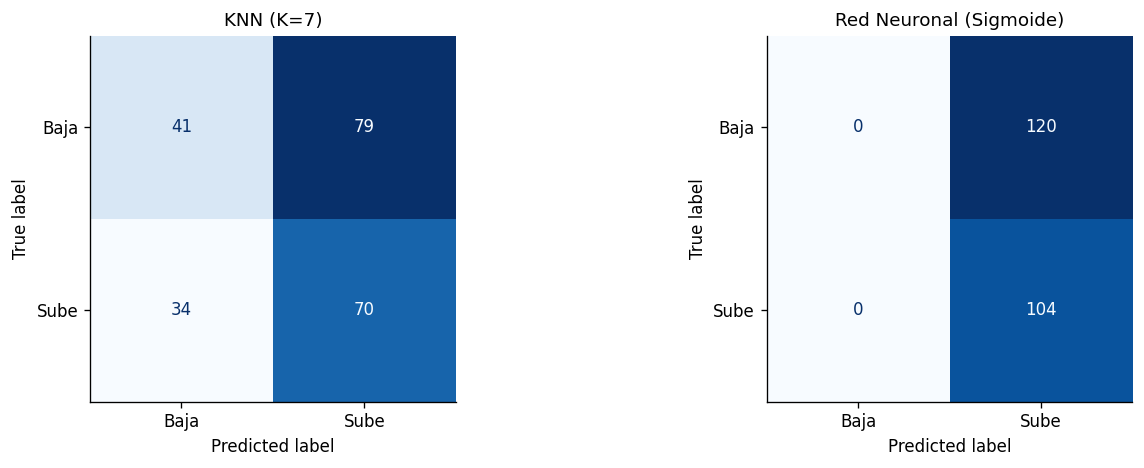

💾 Guardado: fig_confusion_matrices.png


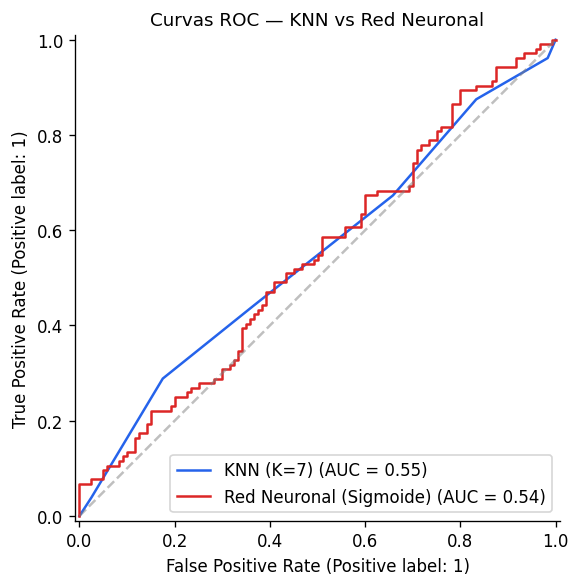

💾 Guardado: fig_roc_curves.png

=== TABLA COMPARATIVA FINAL ===
                       Modelo  Accuracy (%)  Precision  Recall  F1-Score  AUC-ROC
                    KNN (K=7)         49.55     0.4698  0.6731    0.5534   0.5472
Red Neuronal (Sigmoide 32-16)         46.43     0.4643  1.0000    0.6341   0.5407

💾 Guardado: resultados_comparativos.csv


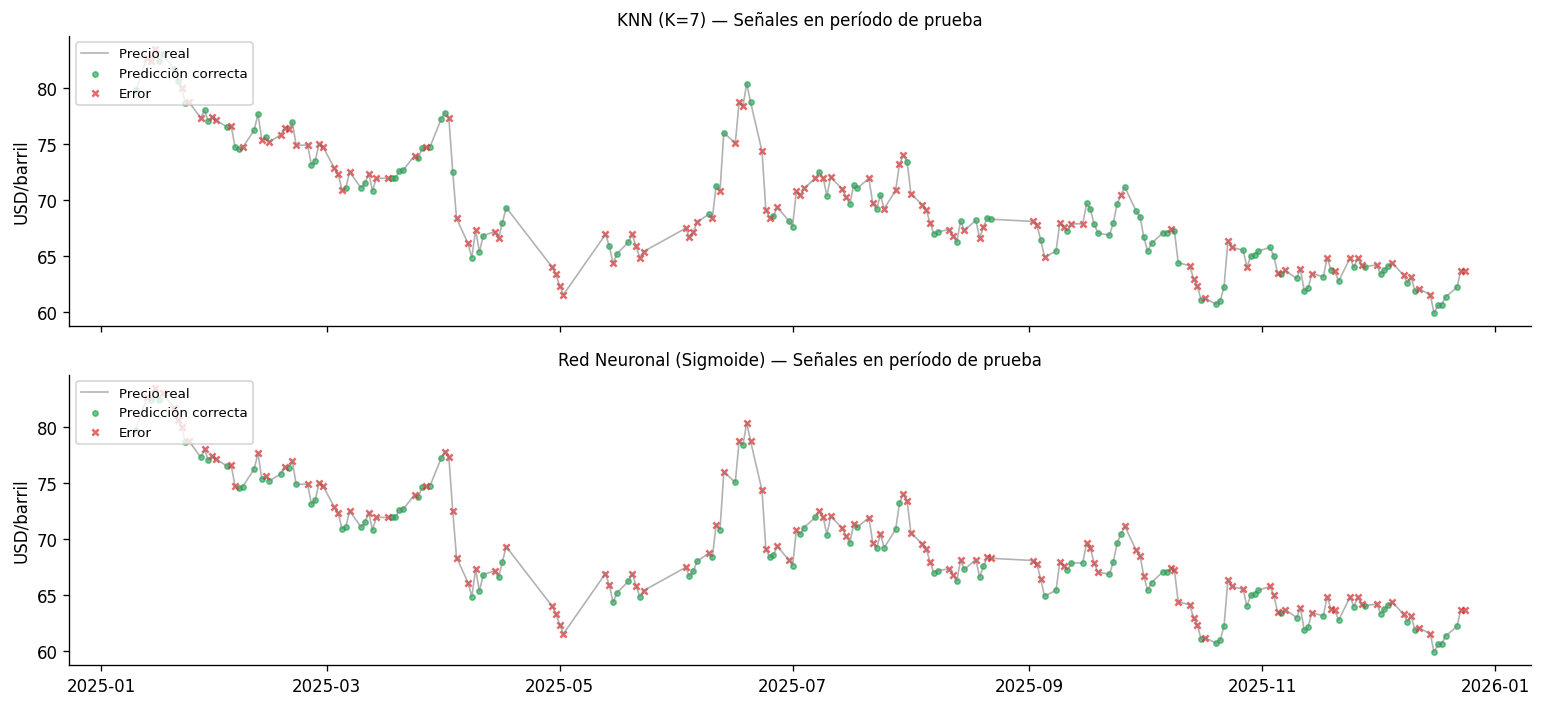

💾 Guardado: fig_signals_test.png
=== Validación Cruzada (5-Fold) — F1 en entrenamiento ===
KNN: 59.84% ± 4.66%
NN : 69.44% ± 0.12%

(Si CV ≈ Test → sin sobreajuste significativo)
  RESUMEN DE MÉTRICAS — COPIA AL DOCUMENTO LaTeX
  Dataset: 1304 obs. | Lags: 5 | Split: 80/20
  Train: 893 | Test: 224


NameError: name 'nan_count' is not defined

In [ ]:
#EValuacion comparativa
# ── Matrices de confusión lado a lado ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
for ax, y_pred, title in zip(
    axes,
    [y_pred_knn, y_pred_nn],
    [f'KNN (K={best_k})', 'Red Neuronal (Sigmoide)']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baja', 'Sube'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11)
 
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Guardado: fig_confusion_matrices.png')
 
#  Curvas ROC comparativas 
fig, ax = plt.subplots(figsize=(6, 5))
 
RocCurveDisplay.from_predictions(y_test, y_prob_knn, name=f'KNN (K={best_k})',         ax=ax, color='#2563EB')
RocCurveDisplay.from_predictions(y_test, y_prob_nn,  name='Red Neuronal (Sigmoide)',    ax=ax, color='#DC2626')
 
ax.plot([0,1], [0,1], linestyle='--', color='gray', alpha=0.5)
ax.set_title('Curvas ROC — KNN vs Red Neuronal', fontsize=11)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig_roc_curves.png')
 
# ── Tabla comparativa de métricas ──
results = pd.DataFrame({
    'Modelo': [f'KNN (K={best_k})', 'Red Neuronal (Sigmoide 32-16)'],
    'Accuracy (%)':  [round(knn_acc*100, 2), round(nn_acc*100, 2)],
    'Precision':     [round(knn_prec, 4),    round(nn_prec, 4)],
    'Recall':        [round(knn_rec, 4),     round(nn_rec, 4)],
    'F1-Score':      [round(knn_f1, 4),      round(nn_f1, 4)],
    'AUC-ROC':       [round(knn_auc, 4),     round(nn_auc, 4)],
})
 
print('\n=== TABLA COMPARATIVA FINAL ===')
print(results.to_string(index=False))
 
# Guardar como CSV para usar en el LaTeX
results.to_csv('resultados_comparativos.csv', index=False)
print('\n💾 Guardado: resultados_comparativos.csv')
 
# ── Predicción visual: señales en el período de prueba ──
test_dates  = feat_df.index[split_idx:]
test_prices = feat_df['price'].values[split_idx:]
 
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
 
for ax, y_pred, title, color in zip(
    axes,
    [y_pred_knn, y_pred_nn],
    [f'KNN (K={best_k})', 'Red Neuronal (Sigmoide)'],
    ['#2563EB', '#DC2626']
):
    ax.plot(test_dates, test_prices, color='gray', linewidth=1, alpha=0.6, label='Precio real')
    # Señales correctas
    correct = y_pred == y_test
    ax.scatter(test_dates[correct],  test_prices[correct],  s=10, color='#16A34A', alpha=0.6, label='Predicción correcta')
    ax.scatter(test_dates[~correct], test_prices[~correct], s=14, color='#DC2626', alpha=0.7, marker='x', label='Error')
    ax.set_title(f'{title} — Señales en período de prueba', fontsize=10)
    ax.set_ylabel('USD/barril')
    ax.legend(fontsize=8, loc='upper left')
 
plt.tight_layout()
plt.savefig('fig_signals_test.png', bbox_inches='tight')
plt.show()
print('💾 Guardado: fig_signals_test.png')
 
# ── Validación cruzada 5-fold en conjunto de entrenamiento (overfit check) ──
cv = StratifiedKFold(n_splits=5, shuffle=False)
 
knn_cv = cross_val_score(knn_model, X_train_sc, y_train, cv=cv, scoring='f1')
nn_cv  = cross_val_score(nn_model,  X_train_sc, y_train, cv=cv, scoring='f1')
 
print('=== Validación Cruzada (5-Fold) — F1 en entrenamiento ===')
print(f'KNN: {knn_cv.mean()*100:.2f}% ± {knn_cv.std()*100:.2f}%')
print(f'NN : {nn_cv.mean()*100:.2f}% ± {nn_cv.std()*100:.2f}%')
print('\n(Si CV ≈ Test → sin sobreajuste significativo)')
 
# Resumen final para copiar al LaTeX 
print('='*55)
print('  RESUMEN DE MÉTRICAS — COPIA AL DOCUMENTO LaTeX')
print('='*55)
print(f'  Dataset: {len(df)} obs. | Lags: {LAG} | Split: 80/20')
print(f'  Train: {len(X_train)} | Test: {len(X_test)}')
print(f'  NaNs imputados: {nan_count} (interpolación lineal)')
print(f'  Balance clases: {y.mean()*100:.1f}% sube / {(1-y).mean()*100:.1f}% baja')
print('-'*55)
print(f'  KNN  | K={best_k} | Acc={knn_acc*100:.2f}% | F1={knn_f1:.4f} | AUC={knn_auc:.4f}')
print(f'  NN   | 5→32→16→1 | Acc={nn_acc*100:.2f}% | F1={nn_f1:.4f} | AUC={nn_auc:.4f}')
print('-'*55)
print(f'  KNN CV F1: {knn_cv.mean()*100:.2f}% ± {knn_cv.std()*100:.2f}%')
print(f'  NN  CV F1: {nn_cv.mean()*100:.2f}% ± {nn_cv.std()*100:.2f}%')
print('='*55)